In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
sns.set_style("whitegrid")

In [2]:
df = pd.read_excel("Ecommerce Sales Analysis.xlsx")

# Data Transformation, Cleansing, Wrangling & Preparation

In [3]:
df[:3]

,Row ID,Order ID,Year,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,2013,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2013-152156,2013,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2013-138688,2013,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


In [4]:
df.head(3)

,Row ID,Order ID,Year,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,2013,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2013-152156,2013,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2013-138688,2013,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Year           9994 non-null   int64         
 3   Order Date     9994 non-null   datetime64[ns]
 4   Ship Date      9994 non-null   datetime64[ns]
 5   Ship Mode      9994 non-null   object        
 6   Customer ID    9994 non-null   object        
 7   Customer Name  9994 non-null   object        
 8   Segment        9994 non-null   object        
 9   Country        9994 non-null   object        
 10  City           9994 non-null   object        
 11  State          9994 non-null   object        
 12  Postal Code    9994 non-null   int64         
 13  Region         9994 non-null   object        
 14  Product ID     9994 non-null   object        
 15  Category       9994 n

In [6]:
df.shape

(9994, 22)

In [7]:
print(df.columns)
print("\n===================================\n")
print(df.dtypes)

Index(['Row ID', 'Order ID', 'Year', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')


Row ID                    int64
Order ID                 object
Year                      int64
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit  

In [8]:
df["Row ID"] = df["Row ID"].astype(object)

In [9]:
df.drop(columns = ["Postal Code"] , inplace = True)

In [10]:
df = df.drop(columns = ["Discount"])

In [11]:
df["Ship Date"] = df["Ship Date"].astype(object)

In [12]:
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [13]:
df["Month"] = df["Ship Date"].dt.month_name()

In [14]:
df.rename( columns = {"Sales" : "Turnover" , "Quantity" : "Sales Volume"} , inplace = True )

# EDA ==========> Exploratory Data Analysis

In [15]:
df.tail()

,Row ID,Order ID,Year,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,...,State,Region,Product ID,Category,Sub-Category,Product Name,Turnover,Sales Volume,Profit,Month
9989,9990,CA-2011-110422,2011,2011-01-22,2011-01-24,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,...,Florida,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,4.1028,January
9990,9991,CA-2014-121258,2014,2014-02-27,2014-03-04,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,California,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,15.6332,March
9991,9992,CA-2014-121258,2014,2014-02-27,2014-03-04,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,California,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,19.3932,March
9992,9993,CA-2014-121258,2014,2014-02-27,2014-03-04,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,California,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,13.3200,March
9993,9994,CA-2014-119914,2014,2014-05-05,2014-05-10,Second Class,CC-12220,Chris Cortes,Consumer,United States,...,California,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,72.9480,May


2014    3319
2013    2580
2012    2102
2011    1993
Name: Year, dtype: int64


AxesSubplot(0.125,0.11;0.775x0.77)


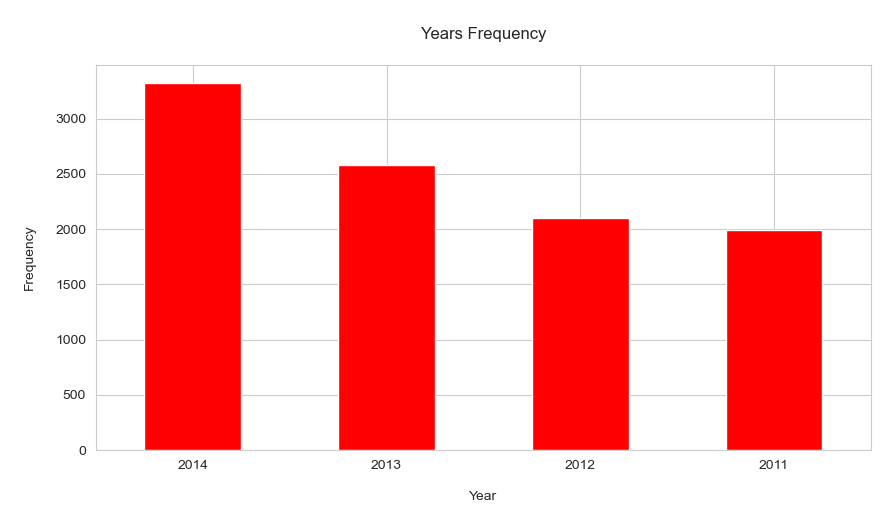

In [16]:
print(df["Year"].value_counts())

print("\n=============================================\n")
plt.figure(figsize = (10 , 5))
print(df["Year"].value_counts().plot.bar(color = "red"))

plt.title("\nYears Frequency\n")
plt.xlabel("\nYear\n")
plt.ylabel("\nFrequency\n")
plt.grid(True)
plt.xticks(rotation = 0.25)

plt.show()

In [17]:
df.groupby(["Year"] , as_index = False)["Row ID"].count().sort_values( by = "Row ID" , ascending = False)

,Year,Row ID
3,2014,3319
2,2013,2580
1,2012,2102
0,2011,1993


In [18]:
df.pivot_table( index = "Year" , values = "Row ID" , aggfunc = "count" ).sort_values(by = "Row ID" , ascending = False)

,Row ID
Year,
2014,3319
2013,2580
2012,2102
2011,1993


In [19]:
def Categoricaldata(df , Column):
    
    Data = df[Column].value_counts()
    print(Data)
    print("\n==========================================================================================================\n")
    plt.figure( figsize = (10 , 5) )
    print(Data.plot.bar( color = "blue" ))
    plt.title("\nFrequency of " + Column)
    plt.xlabel(Column)
    plt.ylabel("\nFrequency\n")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation = 0.25)
    plt.show()
    
    


2014    3319
2013    2580
2012    2102
2011    1993
Name: Year, dtype: int64


AxesSubplot(0.125,0.11;0.775x0.77)


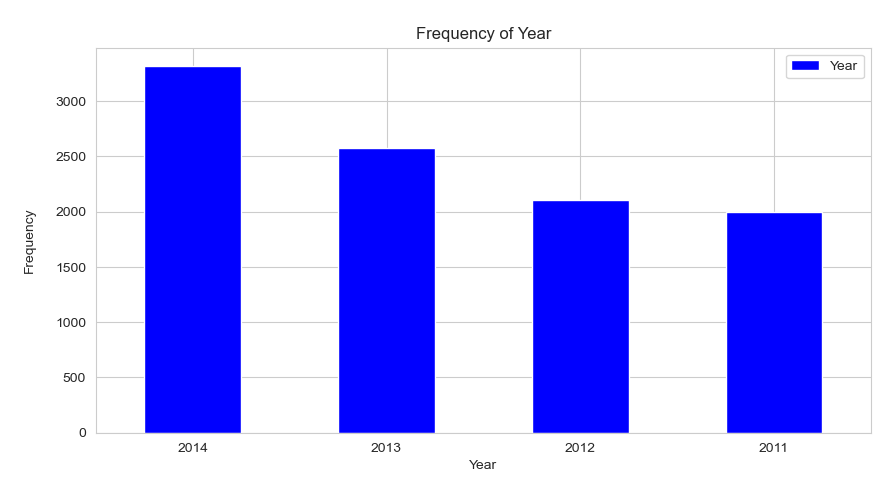

In [20]:
Categoricaldata(df , "Year")

Consumer       5191
Corporate      3020
Home Office    1783
Name: Segment, dtype: int64


AxesSubplot(0.125,0.11;0.775x0.77)


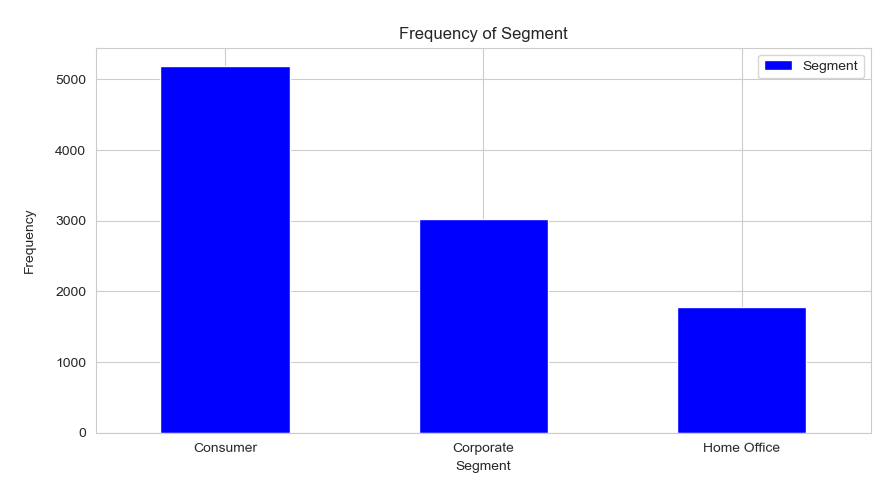

In [21]:
Categoricaldata(df , "Segment")

West       3203
East       2848
Central    2323
South      1620
Name: Region, dtype: int64


AxesSubplot(0.125,0.11;0.775x0.77)


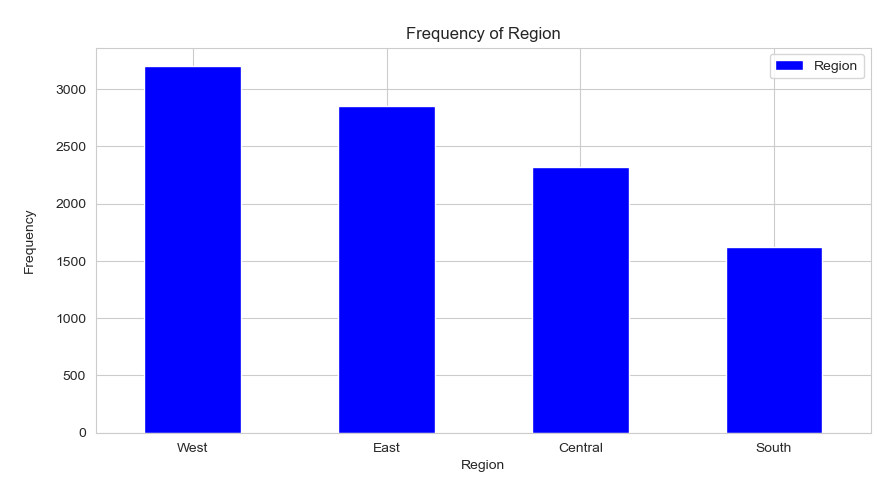

In [22]:
Categoricaldata(df , "Region")

Office Supplies    6026
Furniture          2121
Technology         1847
Name: Category, dtype: int64


AxesSubplot(0.125,0.11;0.775x0.77)


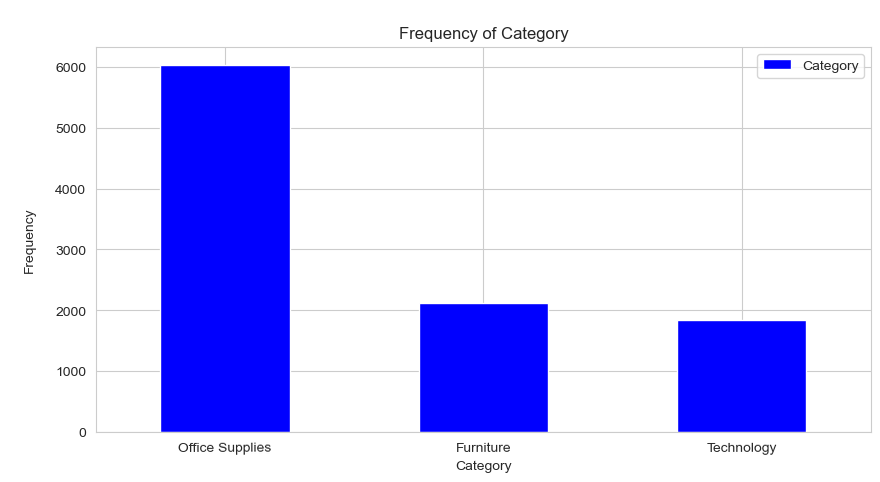

In [23]:
Categoricaldata(df , "Category")

Binders        1523
Paper          1370
Furnishings     957
Phones          889
Storage         846
Art             796
Accessories     775
Chairs          617
Appliances      466
Labels          364
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: Sub-Category, dtype: int64


AxesSubplot(0.125,0.11;0.775x0.77)


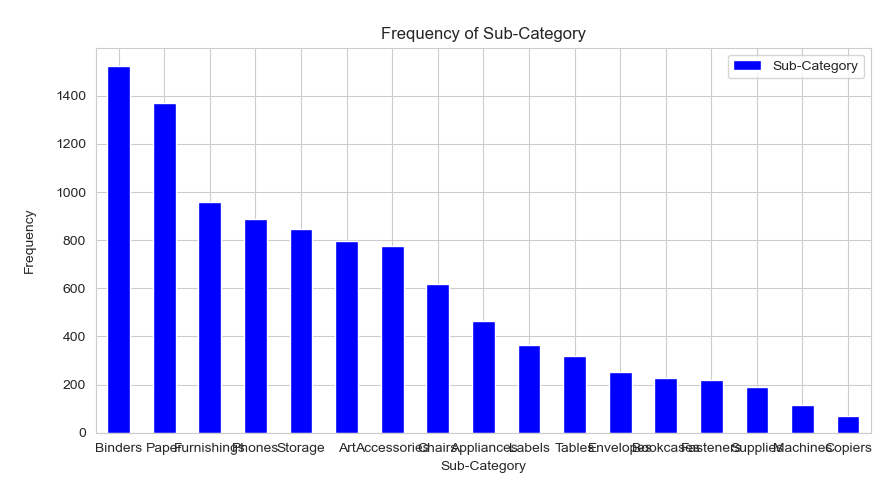

In [24]:
Categoricaldata(df , "Sub-Category")

In [25]:
def getpiechar( df , Name):
    
    Lables = df[Name].value_counts()
    print(Lables)
    print("\n==============================================================================================================\n")
    plt.figure(figsize = (10 , 5))
    print(Lables.plot.pie( autopct = "%1.1f%%"))
    plt.show()

Consumer       5191
Corporate      3020
Home Office    1783
Name: Segment, dtype: int64


AxesSubplot(0.32,0.11;0.385x0.77)


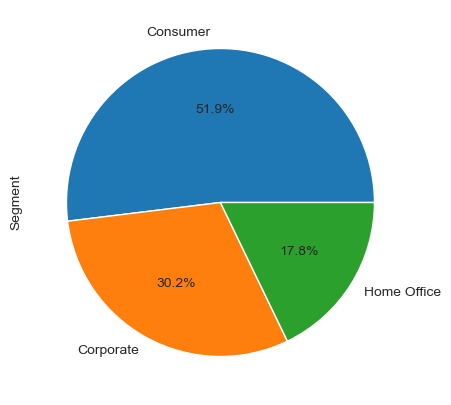

In [26]:
getpiechar(df , "Segment")

2014    3319
2013    2580
2012    2102
2011    1993
Name: Year, dtype: int64


AxesSubplot(0.32,0.11;0.385x0.77)


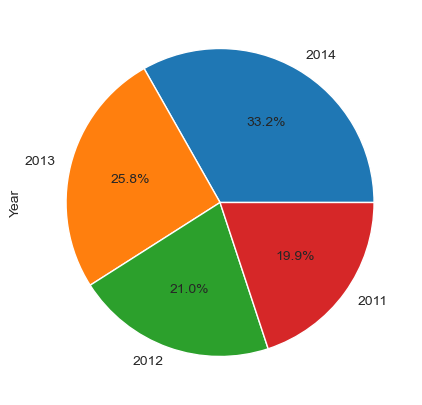

In [27]:
getpiechar( df , "Year")

Office Supplies    6026
Furniture          2121
Technology         1847
Name: Category, dtype: int64


AxesSubplot(0.32,0.11;0.385x0.77)


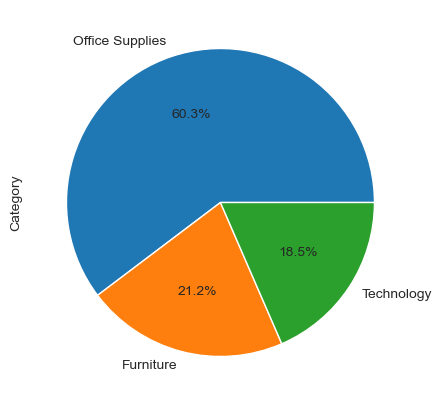

In [28]:
getpiechar(df , "Category")

In [29]:
df.head()

,Row ID,Order ID,Year,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,...,State,Region,Product ID,Category,Sub-Category,Product Name,Turnover,Sales Volume,Profit,Month
0,1,CA-2013-152156,2013,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,...,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,41.9136,November
1,2,CA-2013-152156,2013,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,...,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,219.5820,November
2,3,CA-2013-138688,2013,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,...,California,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,6.8714,June
3,4,US-2012-108966,2012,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,Florida,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,-383.0310,October
4,5,US-2012-108966,2012,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,Florida,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,2.5164,October


# Statistical Insights

In [30]:
df.describe().round(0).T

,count,mean,std,min,25%,50%,75%,max
Year,9994.0,2013.0,1.0,2011.0,2012.0,2013.0,2014.0,2014.0
Turnover,9994.0,230.0,623.0,0.0,17.0,54.0,210.0,22638.0
Sales Volume,9994.0,4.0,2.0,1.0,2.0,3.0,5.0,14.0
Profit,9994.0,29.0,234.0,-6600.0,2.0,9.0,29.0,8400.0


In [31]:
df["Sales Volume"].sum()

37873

In [32]:
df["Sales Volume"].count()

9994

In [33]:
df["Sales Volume"].median()

3.0

In [34]:
df["Sales Volume"].quantile(0.25)

2.0

In [35]:
df["Sales Volume"].quantile(0.5)

3.0

In [36]:
df["Sales Volume"].quantile(0.75)

5.0

In [37]:
df["Sales Volume"].std()

2.2251096911414274

In [38]:
df["Sales Volume"].var()

4.951113137611498

In [39]:
df["Sales Volume"].max()

14

In [40]:
df["Sales Volume"].min()

1

# KPIs & Measures Calculations

In [41]:
df["Unit Price"] =  (df["Turnover"] / df["Sales Volume"])

In [42]:
print("\n================================ Most Significant KPIs ===============================================\n")
print( f'Revenues = {df["Turnover"].sum()}' )
print("\n======================================================================================================\n")
print( f'Avg Revenues = {df["Turnover"].mean()}' )
print("\n======================================================================================================\n")
print( f'Avg Unit Price = {df["Unit Price"].mean()}' )
print("\n======================================================================================================\n")
print( f'Sales Volume = {df["Sales Volume"].sum()}' )


================================ Most Significant KPIs ===============================================

Revenues = 2297200.8603000003


Avg Revenues = 229.8580008304938


Avg Unit Price = 60.91956905143022


Sales Volume = 37873


In [43]:
print("\n================================ Turnover for Each Year ===============================================\n")
print(df.groupby(["Year"] , as_index = False )["Turnover"].sum().sort_values(by = "Turnover" , ascending = False))


================================ Turnover for Each Year ===============================================

   Year     Turnover
3  2014  733947.0232
2  2013  608473.8300
0  2011  484247.4981
1  2012  470532.5090


In [44]:
df.pivot_table( index = "Year" , values = "Turnover" , aggfunc = "sum").sort_values(by = "Turnover" ,ascending = False)

,Turnover
Year,
2014,733947.0232
2013,608473.8300
2011,484247.4981
2012,470532.5090


In [45]:
# Constructing Aggregation Function

def aggragatefunction( df , Text , Insight):
    
    data = df.pivot_table( index = Text , values = Insight , aggfunc = "sum").sort_values(by = "Turnover" , ascending = False)
    print(data)
    print("\n=============================================================================================================\n")
    plt.figure(figsize = (20 , 5))
    data.plot.bar( color = 'r' )
    
    plt.title(Insight + " by " + Text , fontsize = 15)
    plt.xlabel(Text , fontsize = 10)
    plt.ylabel(Insight , fontsize = 10)
    plt.xticks(rotation = 0.25)
    plt.grid( axis = 'y' , linestyle = "--" , alpha = 0.7)
       
    plt.show()

                 Turnover
Segment                  
Consumer     1.161401e+06
Corporate    7.061464e+05
Home Office  4.296531e+05




<Figure size 2000x500 with 0 Axes>

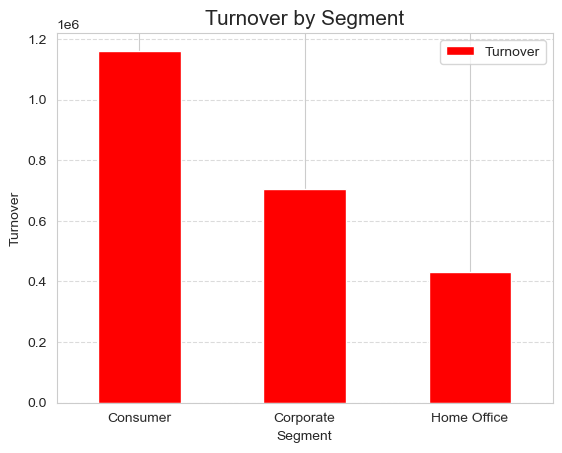

In [46]:
aggragatefunction(df , "Segment" , "Turnover")

         Turnover
Year             
2014  733947.0232
2013  608473.8300
2011  484247.4981
2012  470532.5090




<Figure size 2000x500 with 0 Axes>

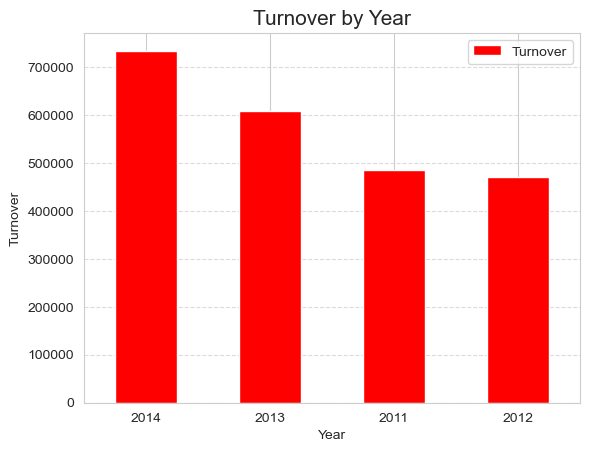

In [47]:
aggragatefunction( df , "Year" , "Turnover")

In [48]:
df.head()

,Row ID,Order ID,Year,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,...,Region,Product ID,Category,Sub-Category,Product Name,Turnover,Sales Volume,Profit,Month,Unit Price
0,1,CA-2013-152156,2013,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,41.9136,November,130.9800
1,2,CA-2013-152156,2013,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,219.5820,November,243.9800
2,3,CA-2013-138688,2013,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,6.8714,June,7.3100
3,4,US-2012-108966,2012,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,-383.0310,October,191.5155
4,5,US-2012-108966,2012,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,2.5164,October,11.1840


In [49]:
df["Quarter"] = df["Order Date"].dt.quarter

In [50]:
df["Day Name"] = df["Order Date"].dt.day_name()

In [51]:
df["Quarter"] = df["Quarter"].astype(object)

In [52]:
df["Quarter Name"] = "Q " + df["Quarter"].astype(str)

In [53]:
Monthlysales = df.groupby(["Month"])["Turnover"].sum()

Quarterlysales = df.groupby(["Quarter Name"])["Turnover"].sum()

Annuallysales = df.groupby(["Year"])["Turnover"].sum()

Dailysales = df.groupby(["Day Name"])["Turnover"].sum()

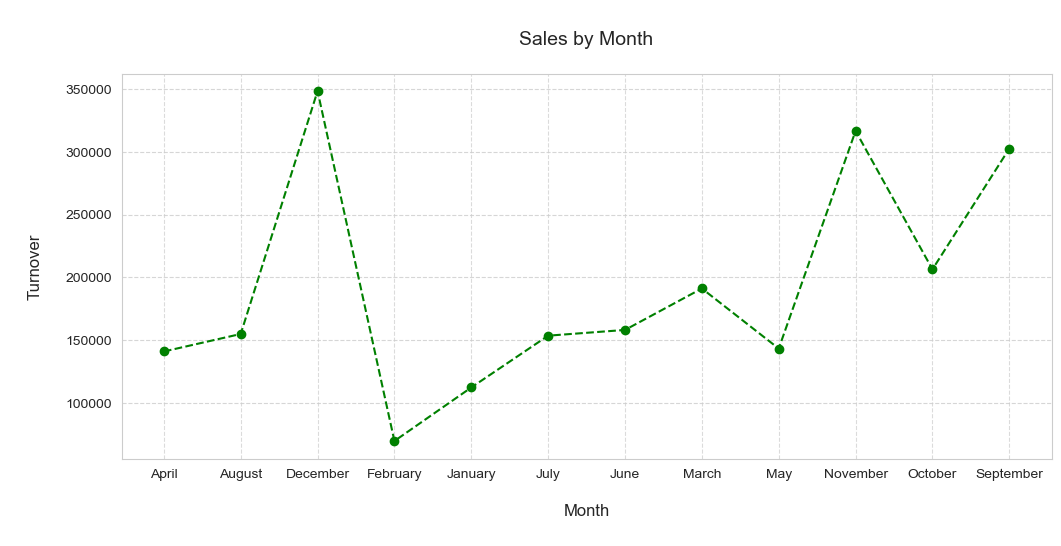

In [54]:
plt.figure(figsize = (12 , 5))
plt.plot(Monthlysales.index , Monthlysales.values , marker = 'o' , linestyle = "--" , color = 'g')
plt.title("\nSales by Month\n" , fontsize = 14)
plt.xlabel("\nMonth\n" , fontsize = 12)
plt.ylabel("\nTurnover\n" , fontsize = 12)
           
plt.grid(axis = 'y' , linestyle = '--' , alpha = 0.8)
plt.grid(axis = 'x' , linestyle = '--' , alpha = 0.7)

plt.show()


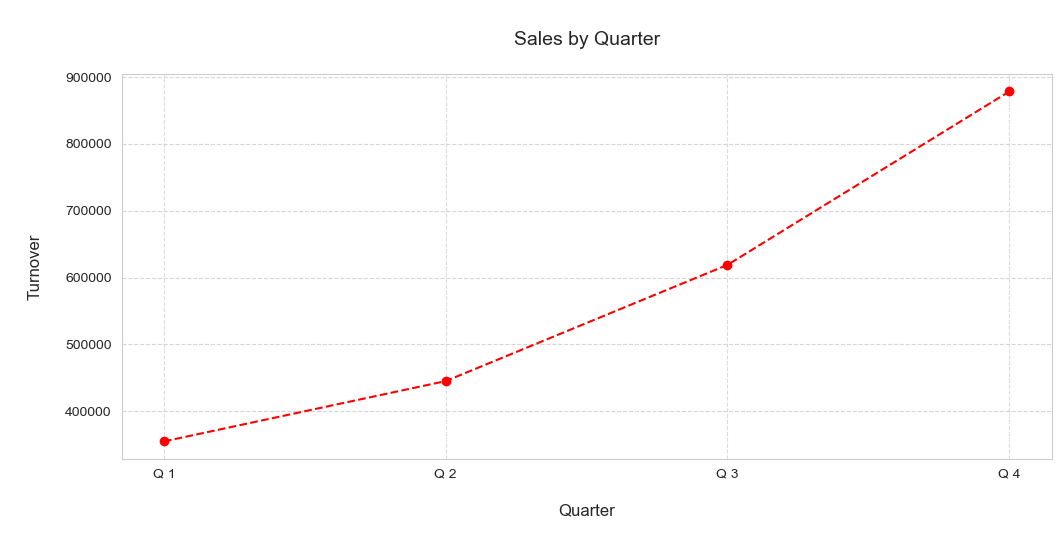

In [55]:
plt.figure(figsize = (12 , 5))
plt.plot(Quarterlysales.index , Quarterlysales.values , marker = 'o' , linestyle = "--" , color = 'r')
plt.title("\nSales by Quarter\n" , fontsize = 14)
plt.xlabel("\nQuarter\n" , fontsize = 12)
plt.ylabel("\nTurnover\n" , fontsize = 12)
           
plt.grid(axis = 'y' , linestyle = '--' , alpha = 0.8)
plt.grid(axis = 'x' , linestyle = '--' , alpha = 0.7)

plt.show()


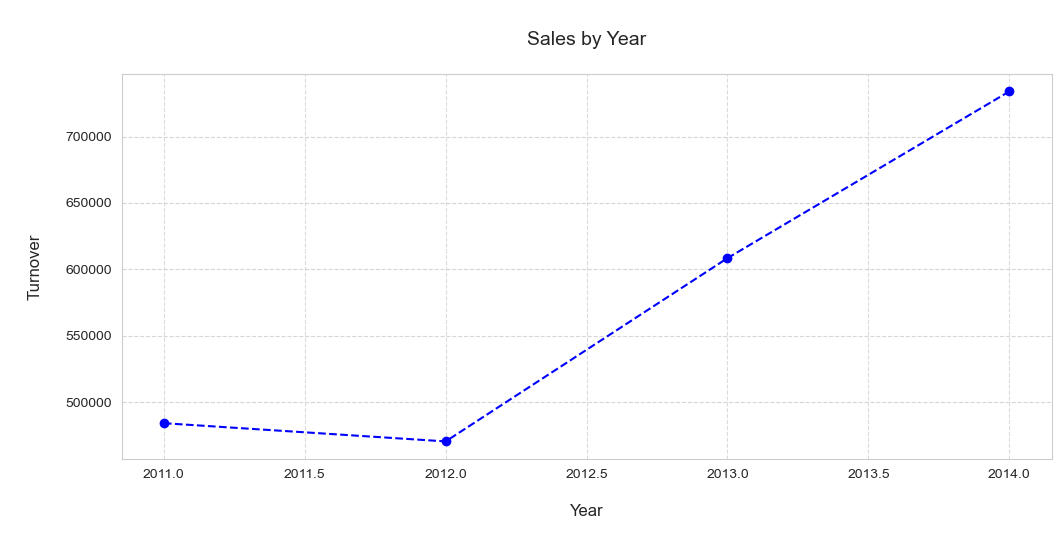

In [56]:
plt.figure(figsize = (12 , 5))
plt.plot(Annuallysales.index , Annuallysales.values , marker = 'o' , linestyle = "--" , color = 'b')
plt.title("\nSales by Year\n" , fontsize = 14)
plt.xlabel("\nYear\n" , fontsize = 12)
plt.ylabel("\nTurnover\n" , fontsize = 12)
           
plt.grid(axis = 'y' , linestyle = '--' , alpha = 0.8)
plt.grid(axis = 'x' , linestyle = '--' , alpha = 0.7)

plt.show()

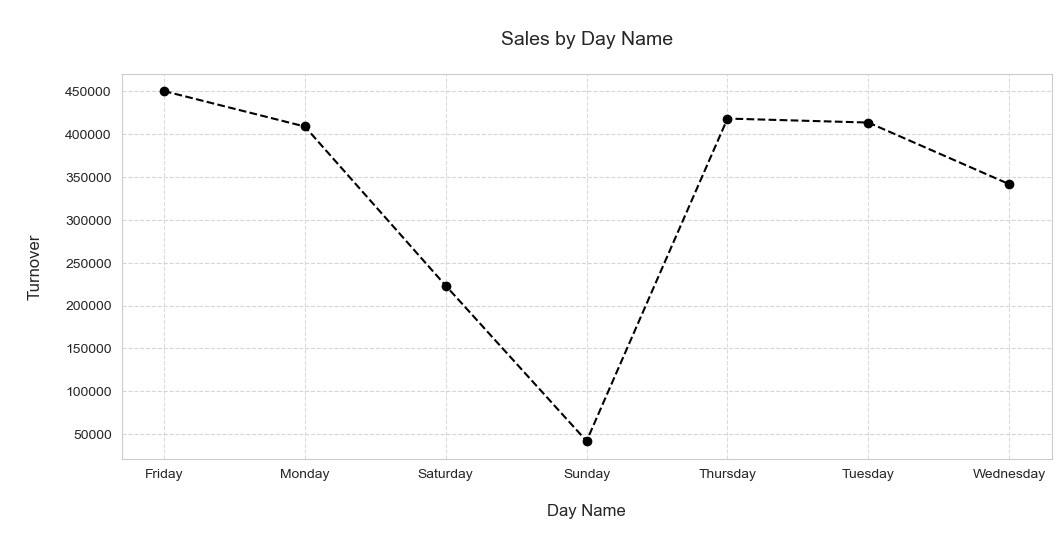

In [57]:
plt.figure(figsize = (12 , 5))
plt.plot(Dailysales.index , Dailysales.values , marker = 'o' , linestyle = "--" , color = 'black')
plt.title("\nSales by Day Name\n" , fontsize = 14)
plt.xlabel("\nDay Name\n" , fontsize = 12)
plt.ylabel("\nTurnover\n" , fontsize = 12)
           
plt.grid(axis = 'y' , linestyle = '--' , alpha = 0.8)
plt.grid(axis = 'x' , linestyle = '--' , alpha = 0.7)

plt.show()

In [58]:
df["Processing Time"] = (df["Ship Date"] - df["Order Date"]).dt.days

In [59]:
df["Processing Time"].value_counts()

4    2771
5    2175
2    1332
6    1201
3    1007
7     621
0     519
1     368
Name: Processing Time, dtype: int64

In [60]:
df["Processing Time"].describe().round()

count    9994.0
mean        4.0
std         2.0
min         0.0
25%         3.0
50%         4.0
75%         5.0
max         7.0
Name: Processing Time, dtype: float64

In [61]:
# Indentify Late Shipments

Service_level_Agreement = 3

df["Late Shipments"] = df["Processing Time"] > Service_level_Agreement

True     6768
False    3226
Name: Late Shipments, dtype: int64
AxesSubplot(0.125,0.11;0.775x0.77)


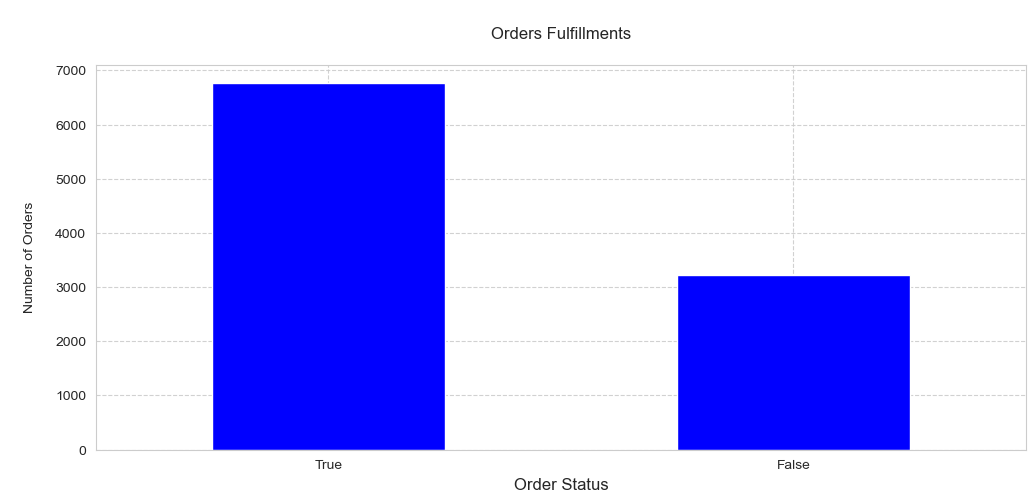

In [62]:
print(df["Late Shipments"].value_counts())

print("=========================================================")

plt.figure(figsize = (12 , 5))
print(df["Late Shipments"].value_counts().plot.bar( color = 'b'))
plt.xticks(rotation = 0.25)

plt.title("\nOrders Fulfillments\n")
plt.xlabel("Order Status" , fontsize = 12)
plt.ylabel("\nNumber of Orders\n")

plt.grid(axis = 'y' , linestyle = '--' , alpha = 0.9)
plt.grid(axis = 'x' , linestyle = '--' , alpha = 0.9)

plt.show()


In [63]:
Shipment_trnds_D = df.groupby(["Day Name"])["Processing Time"].mean().sort_values()

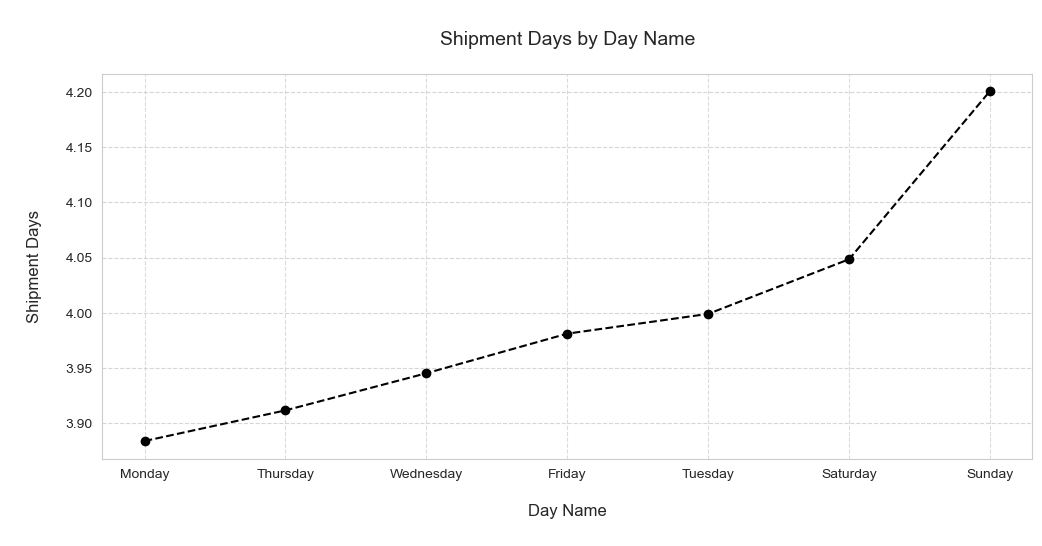

In [64]:
plt.figure(figsize = (12 , 5))
plt.plot(Shipment_trnds_D.index , Shipment_trnds_D.values , marker = 'o' , linestyle = "--" , color = 'black')
plt.title("\nShipment Days by Day Name\n" , fontsize = 14)
plt.xlabel("\nDay Name\n" , fontsize = 12)
plt.ylabel("\nShipment Days\n" , fontsize = 12)
           
plt.grid(axis = 'y' , linestyle = '--' , alpha = 0.8)
plt.grid(axis = 'x' , linestyle = '--' , alpha = 0.7)

plt.show()

True     6768
False    3226
Name: Late Shipments, dtype: int64
AxesSubplot(0.125,0.11;0.775x0.77)


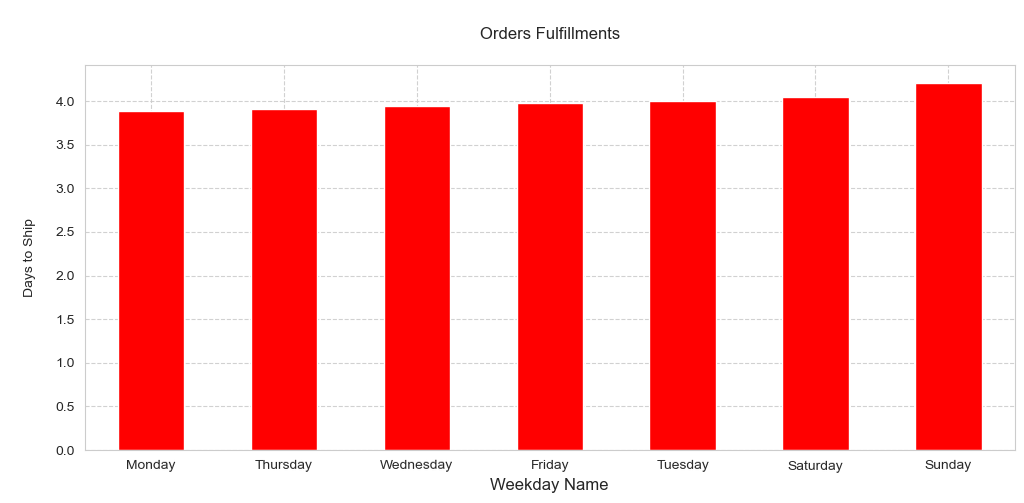

In [65]:
print(df["Late Shipments"].value_counts())

print("=========================================================")

plt.figure(figsize = (12 , 5))
print(Shipment_trnds_D.plot( kind = 'bar' , color = 'r'))
plt.xticks(rotation = 0.25)

plt.title("\nOrders Fulfillments\n")
plt.xlabel("Weekday Name" , fontsize = 12)
plt.ylabel("\nDays to Ship\n")

plt.grid(axis = 'y' , linestyle = '--' , alpha = 0.9)
plt.grid(axis = 'x' , linestyle = '--' , alpha = 0.9)

plt.show()

In [66]:
Late_Orders_Pct = (df["Late Shipments"].sum() / len(df) ) * 100
print(f'Late Orders Percentage : {Late_Orders_Pct:.2f}%')

Late Orders Percentage : 67.72%
